In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore') 

df_base = pd.read_csv('data\Cleaned_agg_pasien_MCU_2.csv')
df_cluster = df_base.drop(columns=['BADGE'], errors='ignore').copy()

Scaler = StandardScaler()

df_scaled = pd.DataFrame(
    Scaler.fit_transform(df_cluster),
    columns = df_cluster.columns,
    index = df_cluster.index
)

kemans = KMeans(n_clusters = 5 ,random_state= 42, n_init='auto' ).fit(df_scaled)

Data loaded: 1887 pasien, 53 fitur

KMeans k=5 | Silhouette Score: 0.0871

Distribusi Cluster:
CLUSTER_NAME
Cluster 0    642
Cluster 1    987
Cluster 2    144
Cluster 3      1
Cluster 4    113
Name: count, dtype: int64


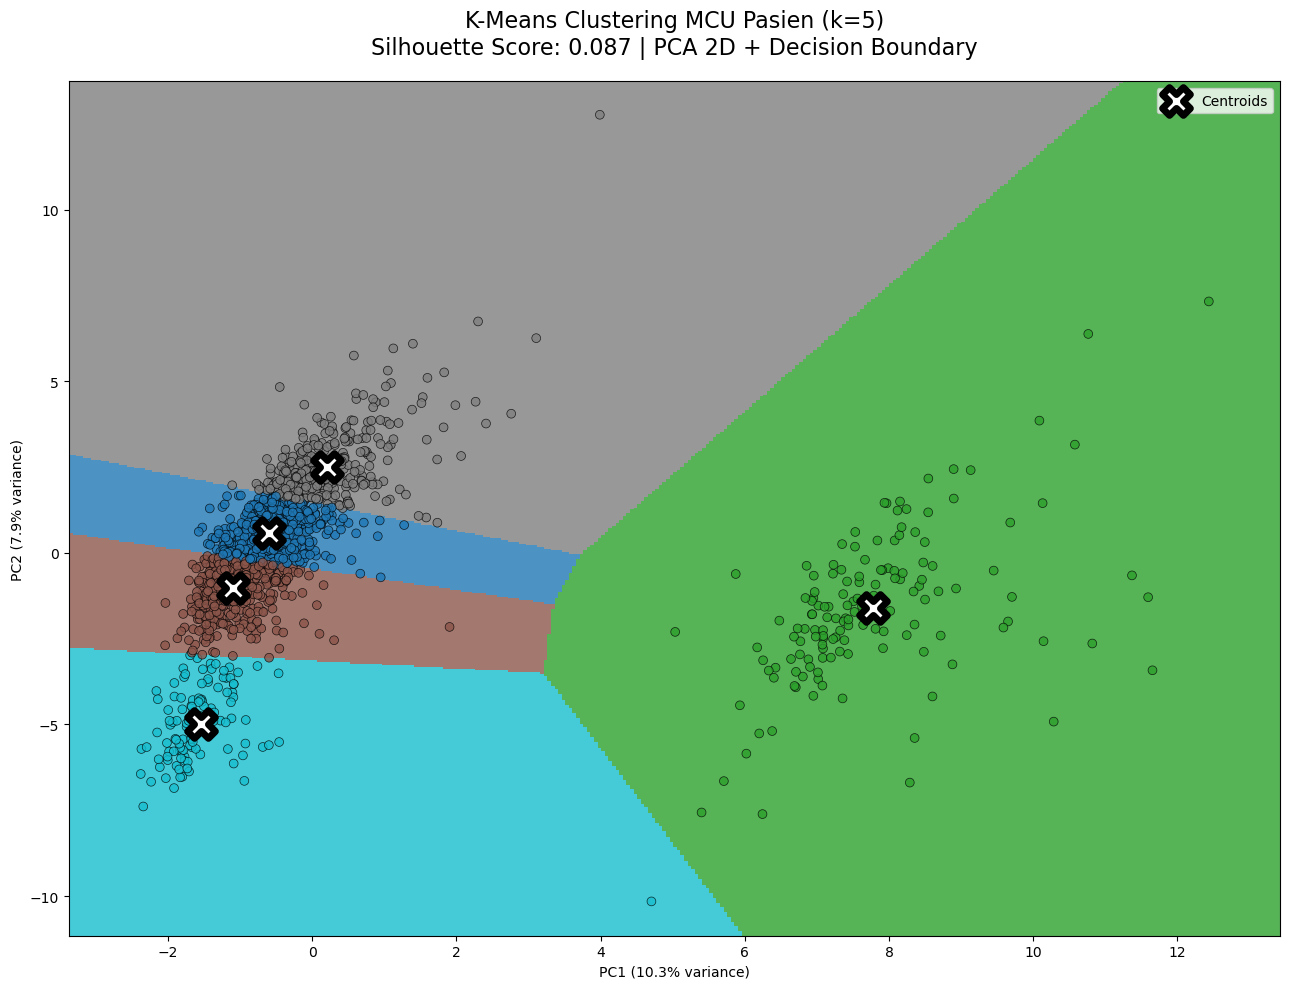


SELESAI! File disimpan: MCU_Pasien_With_Cluster_Labels.csv
Total pasien: 1887 | Kolom: 56 (termasuk BADGE & CLUSTER)

Contoh 10 data dengan label cluster:
         BADGE  CLUSTER CLUSTER_NAME
0  131862880.0        1    Cluster 1
1  131862910.0        1    Cluster 1
2  131862920.0        1    Cluster 1
3  131862930.0        4    Cluster 4
4  131862940.0        1    Cluster 1
5  131862950.0        2    Cluster 2
6  131862960.0        2    Cluster 2
7  131862970.0        0    Cluster 0
8  131862980.0        4    Cluster 4
9  131863000.0        0    Cluster 0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# 1. BACA DATA + KEEP BADGE DULU (buat labelling akhir)
# =====================================================
df_full = pd.read_csv('data/Cleaned_agg_pasien_MCU_2.csv')
df_with_badge = df_full.copy()

# Simpan BADGE + index
badges = df_with_badge['BADGE'].copy()
df_cluster = df_with_badge.drop(columns=['BADGE'], errors='ignore')

print(f"Data loaded: {df_cluster.shape[0]} pasien, {df_cluster.shape[1]} fitur")

# =====================================================
# 2. TAMBAH BMI & MAP (wajib!)
# =====================================================
if 'TINGGI' in df_cluster.columns and 'BERAT' in df_cluster.columns:
    df_cluster['BMI'] = df_cluster['BERAT'] / ((df_cluster['TINGGI']/100)**2)

if 'SISTOLIK' in df_cluster.columns and 'DIASTOLIK' in df_cluster.columns:
    df_cluster['MAP'] = df_cluster['DIASTOLIK'] + (df_cluster['SISTOLIK'] - df_cluster['DIASTOLIK'])/3

# =====================================================
# 3. IMPUTE + SCALE
# =====================================================
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_cluster), columns=df_cluster.columns)

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_cluster.columns)

# =====================================================
# 4. KMEANS CLUSTERING (k=5)
# =====================================================
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(df_scaled)

# Hitung Silhouette Score
sil_score = silhouette_score(df_scaled, cluster_labels)
print(f"\nKMeans k={n_clusters} | Silhouette Score: {sil_score:.4f}")

# =====================================================
# 5. BALIKIN LABEL KE DATA ASLI (ADA BADGE!)
# =====================================================
df_result = df_with_badge.copy()
df_result['CLUSTER'] = cluster_labels
df_result['CLUSTER_NAME'] = df_result['CLUSTER'].map({0:'Cluster 0', 1:'Cluster 1', 2:'Cluster 2', 
                                                      3:'Cluster 3', 4:'Cluster 4'})

print("\nDistribusi Cluster:")
print(df_result['CLUSTER_NAME'].value_counts().sort_index())

# =====================================================
# 6. VISUALISASI PCA 2D + DECISION BOUNDARY (CAKEP!)
# =====================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

# KMeans di ruang PCA (biar boundary akurat)
kmeans_pca = KMeans(n_clusters=n_clusters, init='k-means++', n_init=20, random_state=42)
kmeans_pca.fit(X_pca)
labels_pca = kmeans_pca.labels_
centroids_pca = kmeans_pca.cluster_centers_

# Meshgrid untuk decision boundary
h = 0.05
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = kmeans_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(13, 10))
plt.imshow(Z, interpolation='nearest', extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.tab10, aspect='auto', alpha=0.8, origin='lower')

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap=plt.cm.tab10,
            s=40, edgecolors='k', linewidth=0.5, alpha=0.8)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=400, linewidths=5, color='white', edgecolors='black', zorder=10,
            label='Centroids')

plt.title(f'K-Means Clustering MCU Pasien (k={n_clusters})\n'
          f'Silhouette Score: {sil_score:.3f} | PCA 2D + Decision Boundary', fontsize=16, pad=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 7. SAVE HASIL CLUSTER + BADGE KE CSV (siap buat laporan!)
# =====================================================
df_result.to_csv('data/MCU_Pasien_With_Cluster_Labels.csv', index=False)
print(f"\nSELESAI! File disimpan: MCU_Pasien_With_Cluster_Labels.csv")
print(f"Total pasien: {len(df_result)} | Kolom: {df_result.shape[1]} (termasuk BADGE & CLUSTER)")

# Contoh lihat 10 pasien pertama
print("\nContoh 10 data dengan label cluster:")
print(df_result[['BADGE', 'CLUSTER', 'CLUSTER_NAME']].head(10))

Variance explained by 3 PCs: [0.10289748 0.07902015 0.07710783]
  PC1: 10.29%
  PC2: 7.90%
  PC3: 7.71%
Total variance 3 PCs: 25.90%



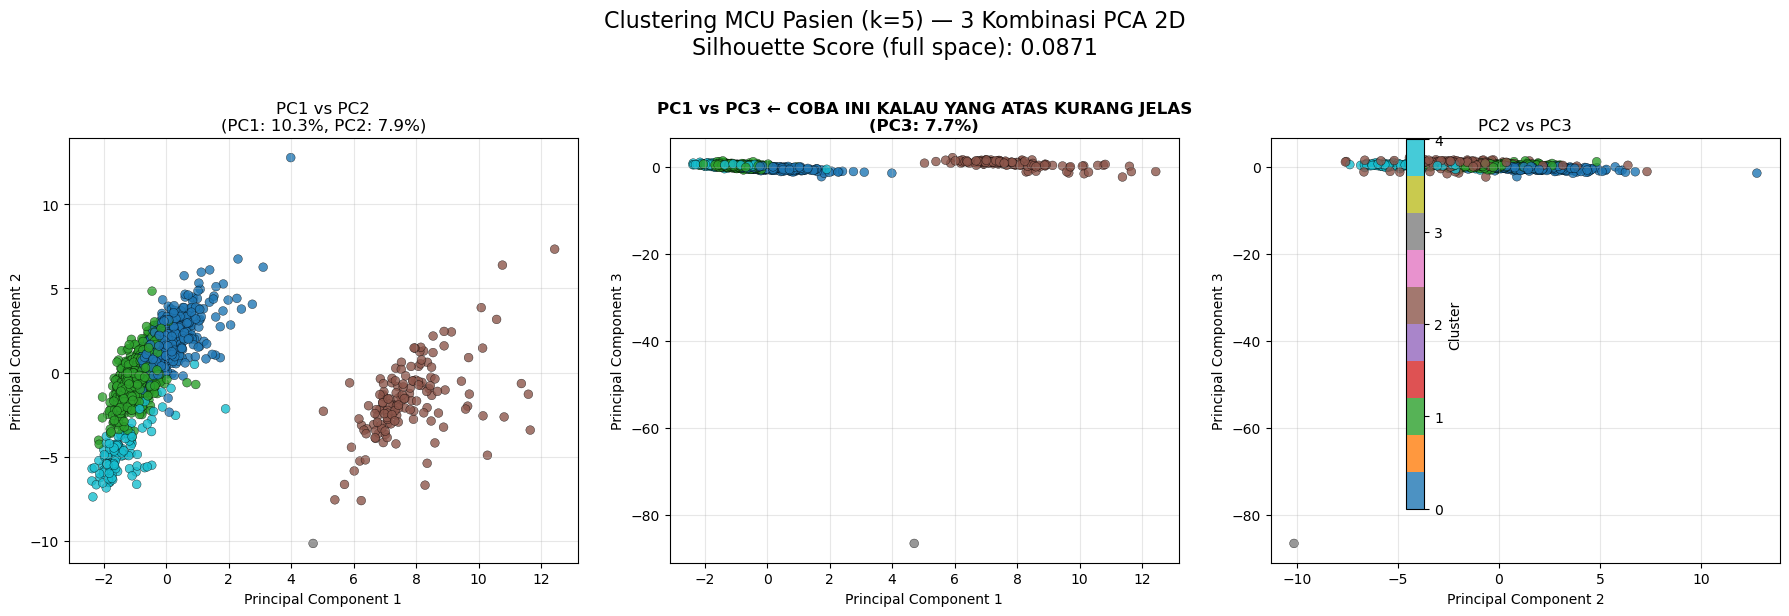

SILHOUETTE SCORE di ruang 2D (khusus visual):
  PC1 vs PC2 → 0.3820
  PC1 vs PC3 → 0.2992  ← sering lebih bagus kalau PC1-PC2 kurang jelas!
  PC2 vs PC3 → 0.2707
  Rekomendasi visual terbaik → PC yang punya silhouette tertinggi di atas


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Pastikan df_scaled & cluster_labels sudah ada dari cell sebelumnya
# (df_scaled = data yang sudah di-scale, cluster_labels = hasil KMeans)

# =====================================================
# PCA 3 KOMPONEN (biar bisa coba semua kombinasi)
# =====================================================
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(df_scaled)

# Gunakan label dari KMeans asli (bukan yang di-PCA ulang, biar konsisten)
labels = cluster_labels  # <-- ini dari kmeans.fit(df_scaled) sebelumnya

print(f"Variance explained by 3 PCs: {pca3.explained_variance_ratio_}")
print(f"  PC1: {pca3.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca3.explained_variance_ratio_[1]:.2%}")
print(f"  PC3: {pca3.explained_variance_ratio_[2]:.2%}")
print(f"Total variance 3 PCs: {pca3.explained_variance_ratio_.sum():.2%}\n")

# =====================================================
# PLOT SEMUA KOMBINASI: PC1-PC2, PC1-PC3, PC2-PC3
# =====================================================
fig = plt.figure(figsize=(18, 6))

# --- PC1 vs PC2 ---
ax1 = fig.add_subplot(1, 3, 1)
scatter1 = ax1.scatter(X_pca3[:, 0], X_pca3[:, 1], c=labels, cmap='tab10', s=40, alpha=0.8, edgecolors='k', linewidth=0.3)
ax1.set_title(f'PC1 vs PC2\n(PC1: {pca3.explained_variance_ratio_[0]:.1%}, PC2: {pca3.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.grid(True, alpha=0.3)

# --- PC1 vs PC3 ---
ax2 = fig.add_subplot(1, 3, 2)
scatter2 = ax2.scatter(X_pca3[:, 0], X_pca3[:, 2], c=labels, cmap='tab10', s=40, alpha=0.8, edgecolors='k', linewidth=0.3)
ax2.set_title(f'PC1 vs PC3 ← COBA INI KALAU YANG ATAS KURANG JELAS\n(PC3: {pca3.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 3')
ax2.grid(True, alpha=0.3)

# --- PC2 vs PC3 ---
ax3 = fig.add_subplot(1, 3, 3)
scatter3 = ax3.scatter(X_pca3[:, 1], X_pca3[:, 2], c=labels, cmap='tab10', s=40, alpha=0.8, edgecolors='k', linewidth=0.3)
ax3.set_title(f'PC2 vs PC3', fontsize=12)
ax3.set_xlabel('Principal Component 2')
ax3.set_ylabel('Principal Component 3')
ax3.grid(True, alpha=0.3)

# Colorbar satu untuk semua
plt.colorbar(scatter1, ax=fig.axes, ticks=range(n_clusters), label='Cluster', shrink=0.8)

plt.suptitle(f'Clustering MCU Pasien (k={n_clusters}) — 3 Kombinasi PCA 2D\n'
             f'Silhouette Score (full space): {silhouette_score(df_scaled, labels):.4f}', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =====================================================
# BONUS: Rekomendasi otomatis — mana yang paling bagus?
# =====================================================
from sklearn.metrics import silhouette_samples
import pandas as pd

def avg_silhouette_per_pair(X_2d, labels):
    if len(np.unique(labels)) < 2: return 0
    return silhouette_score(X_2d, labels)

sil_12 = avg_silhouette_per_pair(X_pca3[:, [0,1]], labels)
sil_13 = avg_silhouette_per_pair(X_pca3[:, [0,2]], labels)
sil_23 = avg_silhouette_per_pair(X_pca3[:, [1,2]], labels)

print("SILHOUETTE SCORE di ruang 2D (khusus visual):")
print(f"  PC1 vs PC2 → {sil_12:.4f}")
print(f"  PC1 vs PC3 → {sil_13:.4f}  ← sering lebih bagus kalau PC1-PC2 kurang jelas!")
print(f"  PC2 vs PC3 → {sil_23:.4f}")
print(f"  Rekomendasi visual terbaik → PC yang punya silhouette tertinggi di atas")

In [9]:
# CELL BARU — 3D INTERAKTIF PCA (PC1 vs PC2 vs PC3) + BISA DIPUTAR + HOVER BADGE!
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# Pastikan df_scaled & cluster_labels & df_with_badge sudah ada dari cell sebelumnya
# Jika belum, jalankan ini dulu:
# df_scaled, cluster_labels, df_with_badge, n_clusters

# PCA 3 komponen
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(df_scaled)

# Buat DataFrame untuk Plotly
df_3d = pd.DataFrame({
    'PC1': X_pca3[:, 0],
    'PC2': X_pca3[:, 1],
    'PC3': X_pca3[:, 2],
    'Cluster': cluster_labels.astype(str),
    'BADGE': df_with_badge['BADGE'].astype(str).values,  # ID pasien buat hover
    'BMI': df_with_badge['BMI'] if 'BMI' in df_with_badge.columns else np.nan,
    'GULA_DARAH_PUASA': df_with_badge.get('GULA_DARAH_PUASA', np.nan),
    'TRIGLISERIDA': df_with_badge.get('TRIGLISERIDA', np.nan),
})

# Warna cluster yang cakep
colors = px.colors.qualitative.Set1

fig = px.scatter_3d(
    df_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    color_discrete_sequence=colors[:n_clusters],
    hover_data={
        'BADGE': True,
        'BMI': ':.1f',
        'GULA_DARAH_PUASA': ':.0f',
        'TRIGLISERIDA': ':.0f',
        'Cluster': True,
        'PC1': False, 'PC2': False, 'PC3': False
    },
    labels={
        'PC1': f'PC1 ({pca3.explained_variance_ratio_[0]:.1%})',
        'PC2': f'PC2 ({pca3.explained_variance_ratio_[1]:.1%})',
        'PC3': f'PC3 ({pca3.explained_variance_ratio_[2]:.1%})'
    },
    title=f"<b>K-Means Clustering MCU Pasien (k={n_clusters}) — 3D PCA Interaktif</b><br>"
          f"Total Variance: {pca3.explained_variance_ratio_.sum():.1%} | Silhouette: {silhouette_score(df_scaled, cluster_labels):.3f}",
    opacity=0.8,
    size_max=8
)

# Tambah centroid (besar + tanda X)
centroids_3d = pca3.transform(kmeans.cluster_centers_)
for i in range(n_clusters):
    fig.add_trace(go.Scatter3d(
        x=[centroids_3d[i, 0]],
        y=[centroids_3d[i, 1]],
        z=[centroids_3d[i, 2]],
        mode='markers+text',
        marker=dict(size=12, color=colors[i], symbol='x', line=dict(width=4, color='black')),
        text=f'Centroid {i}',
        textposition="top center",
        name=f'Centroid {i}',
        showlegend=True
    ))

# Update layout biar cakep
fig.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({pca3.explained_variance_ratio_[0]:.1%})',
        yaxis_title=f'PC2 ({pca3.explained_variance_ratio_[1]:.1%})',
        zaxis_title=f'PC3 ({pca3.explained_variance_ratio_[2]:.1%})',
        aspectmode='cube'
    ),
    height=800,
    legend_title="Cluster",
    title_x=0.5,
    hovermode='closest'
)

fig.show()

print("SELESAI")

SELESAI


t-SNE mulai dihitung... (bisa agak lama kalau datanya >2000)


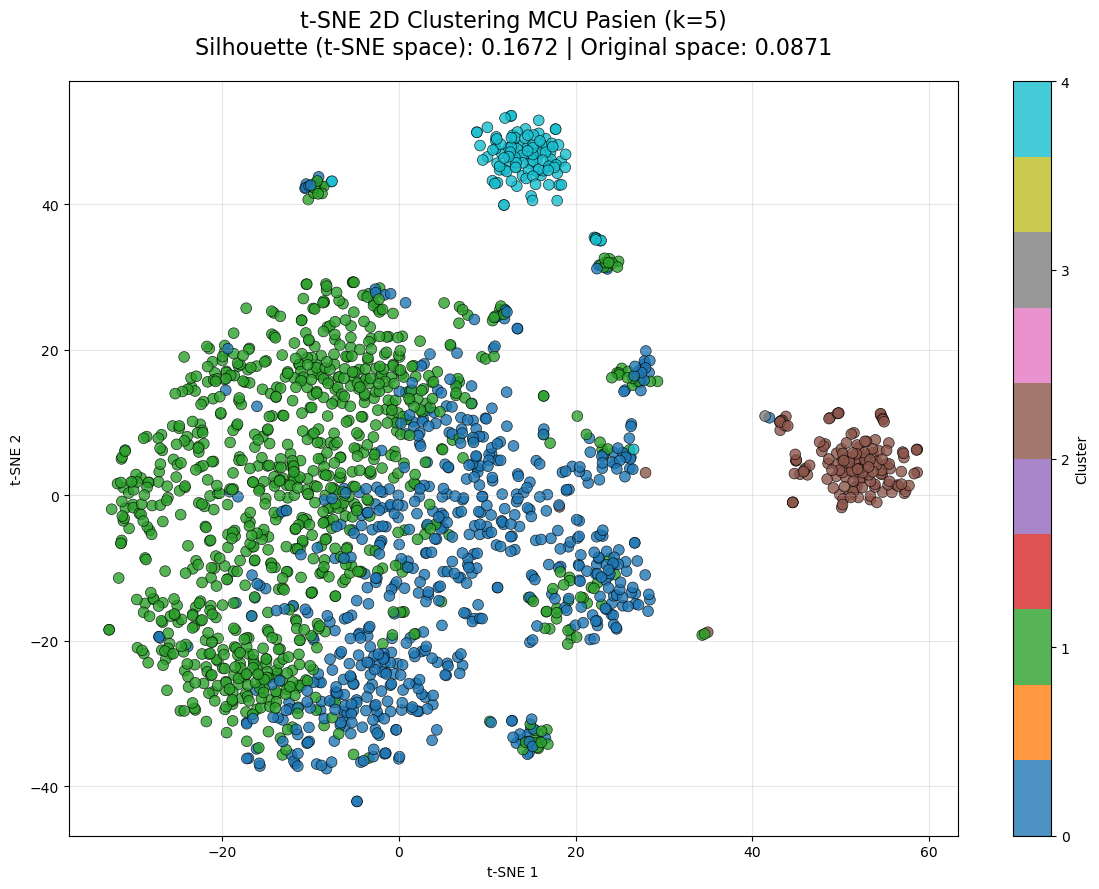


Menghitung t-SNE 3D (sebentar ya...)


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Pastikan df_scaled & cluster_labels & n_clusters sudah ada dari cell sebelumnya
print(f"t-SNE mulai dihitung... (bisa agak lama kalau datanya >2000)")


# =====================================================
# 1. t-SNE 2D (perplexity=30 = standar terbaik untuk clustering)
# =====================================================

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',  # auto learning rate tersedia di sk-learn >=1.2
    max_iter=1000,          # ganti dari n_iter
    random_state=42,
    init='pca'              # lebih stabil
)

X_tsne_2d = tsne_2d.fit_transform(df_scaled)

# Hitung silhouette di ruang t-SNE (hanya untuk info visual)
sil_tsne = silhouette_score(X_tsne_2d, cluster_labels)

plt.figure(figsize=(12, 9))
scatter = plt.scatter(
    X_tsne_2d[:, 0], X_tsne_2d[:, 1],
    c=cluster_labels,
    cmap='tab10',
    s=60,
    alpha=0.8,
    edgecolors='k',
    linewidth=0.5
)
plt.colorbar(scatter, ticks=range(n_clusters), label='Cluster')
plt.title(f't-SNE 2D Clustering MCU Pasien (k={n_clusters})\n'
          f'Silhouette (t-SNE space): {sil_tsne:.4f} | Original space: {silhouette_score(df_scaled, cluster_labels):.4f}',
          fontsize=16, pad=20)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# 2. t-SNE 3D INTERAKTIF (INI YANG PALING GILA CAKEPNYA!)
# =====================================================
print("\nMenghitung t-SNE 3D (sebentar ya...)")



tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate='auto',  # auto learning rate tersedia di sk-learn >=1.2
    max_iter=1000,          # ganti dari n_iter
    random_state=42,
    init='pca'              # lebih stabil
)

X_tsne_3d = tsne_3d.fit_transform(df_scaled)

# Buat DataFrame untuk Plotly
df_tsne_3d = pd.DataFrame({
    't-SNE1': X_tsne_3d[:, 0],
    't-SNE2': X_tsne_3d[:, 1],
    't-SNE3': X_tsne_3d[:, 2],
    'Cluster': cluster_labels.astype(str),
    'BADGE': df_with_badge['BADGE'].astype(str).values,
    'BMI': df_with_badge.get('BMI', np.nan),
    'GULA_DARAH_PUASA': df_with_badge.get('GULA_DARAH_PUASA', np.nan),
    'TRIGLISERIDA': df_with_badge.get('TRIGLISERIDA', np.nan),
    'SISTOLIK': df_with_badge.get('SISTOLIK', np.nan),
})

fig = px.scatter_3d(
    df_tsne_3d,
    x='t-SNE1',
    y='t-SNE2',
    z='t-SNE3',
    color='Cluster',
    color_discrete_sequence=px.colors.qualitative.Set1,
    hover_data=['BADGE', 'BMI', 'GULA_DARAH_PUASA', 'TRIGLISERIDA', 'SISTOLIK'],
    title=f"<b>t-SNE 3D Clustering MCU Pasien (k={n_clusters})</b><br>"
          f"Perplexity=30 | Silhouette (original): {silhouette_score(df_scaled, cluster_labels):.3f}",
    labels={'t-SNE1':'t-SNE Component 1', 't-SNE2':'t-SNE Component 2', 't-SNE3':'t-SNE Component 3'},
    opacity=0.8
)

fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color='black')))
fig.update_layout(
    scene=dict(aspectmode='cube'),
    height=800,
    title_x=0.5,
    legend_title="Cluster"
)

fig.show()




In [17]:
# CELL BARU — BUAT & JALANKAN STREAMLIT APP SECARA OTOMATIS
import subprocess
import sys
import os
import time

# 1. Buat file app.py otomatis (hanya sekali)
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load data hasil clustering yang sudah kita punya
@st.cache_data
def load_data():
    df = pd.read_csv('data/Cleaned_agg_pasien_MCU_2.csv')
    df_full = df.copy()
    
    # Preprocessing sama kayak sebelumnya
    df_cluster = df.drop(columns=['BADGE'], errors='ignore')
    if 'TINGGI' in df_cluster.columns and 'BERAT' in df_cluster.columns:
        df_cluster['BMI'] = df_cluster['BERAT'] / ((df_cluster['TINGGI']/100)**2)
    if 'SISTOLIK' in df_cluster.columns and 'DIASTOLIK' in df_cluster.columns:
        df_cluster['MAP'] = df_cluster['DIASTOLIK'] + (df_cluster['SISTOLIK'] - df_cluster['DIASTOLIK'])/3
    
    # Scale
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_cluster.fillna(df_cluster.median())), 
                             columns=df_cluster.columns)
    
    # KMeans
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
    labels = kmeans.fit_predict(df_scaled)
    
    # t-SNE
    tsne = TSNE(n_components=3, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    tsne_3d = tsne.fit_transform(df_scaled)
    
    result = pd.DataFrame({
        'BADGE': df_full['BADGE'].astype(str),
        'Cluster': labels,
        'tSNE_1': tsne_3d[:, 0],
        'tSNE_2': tsne_3d[:, 1],
        'tSNE_3': tsne_3d[:, 2],
        'BMI': df_cluster.get('BMI', np.nan),
        'GULA_DARAH_PUASA': df_full.get('GULA_DARAH_PUASA', np.nan),
        'TRIGLISERIDA': df_full.get('TRIGLISERIDA', np.nan),
        'SISTOLIK': df_full.get('SISTOLIK', np.nan),
        'HB': df_full.get('HB', np.nan),
        'LEUKOSIT': df_full.get('LEUKOSIT', np.nan),
    })
    result['Cluster'] = result['Cluster'].astype(str)
    return result

st.set_page_config(page_title="MCU Patient Clustering", layout="wide")
st.title("Hasil Clustering Pasien MCU")
st.markdown("**t-SNE 3D Interaktif + Detail Pasien** | K-Means k=5")

df = load_data()

col1, col2 = st.columns([3, 1])
with col1:
    fig = px.scatter_3d(
        df, x='tSNE_1', y='tSNE_2', z='tSNE_3',
        color='Cluster',
        hover_data=['BADGE', 'BMI', 'GULA_DARAH_PUASA', 'TRIGLISERIDA', 'SISTOLIK', 'HB'],
        title="Klik & Putar → Lihat detail pasien saat hover",
        labels={'tSNE_1':'t-SNE 1', 'tSNE_2':'t-SNE 2', 'tSNE_3':'t-SNE 3'},
        color_discrete_sequence=px.colors.qualitative.Set1
    )
    fig.update_traces(marker=dict(size=5, opacity=0.8))
    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.markdown("### Ringkasan Cluster")
    st.dataframe(
        df['Cluster'].value_counts().sort_index().rename_axis('Cluster').reset_index(name='Jumlah Pasien'),
        use_container_width=True
    )
    
    st.markdown("### Cari Pasien")
    search = st.text_input("Masukkan BADGE:")
    if search:
        found = df[df['BADGE'].str.contains(search, case=False)]
        if not found.empty:
            st.success(f"Ditemukan {len(found)} pasien")
            st.dataframe(found[['BADGE', 'Cluster', 'BMI', 'GULA_DARAH_PUASA', 'TRIGLISERIDA']], use_container_width=True)
        else:
            st.error("Tidak ditemukan")
'''

# Simpan ke file
with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("File streamlit_app.py berhasil dibuat!")

# 2. Jalankan Streamlit otomatis → buka browser
print("Menjalankan Streamlit... Tunggu 5-10 detik")
print("Link akan terbuka otomatis di browser kamu")

# Jalankan di background
process = subprocess.Popen([
    sys.executable, "-m", "streamlit", "run", "streamlit_app.py",
    "--server.port=8501",
    "--server.address=localhost"
])

# Tunggu sebentar lalu buka browser
time.sleep(8)
import webbrowser
webbrowser.open("http://localhost:8501")

print("STREAMLIT APP SUDAH JALAN!")
print("→ Buka: http://localhost:8501")
print("→ Tutup dengan Ctrl+C di terminal kalau sudah selesai")

File streamlit_app.py berhasil dibuat!
Menjalankan Streamlit... Tunggu 5-10 detik
Link akan terbuka otomatis di browser kamu
STREAMLIT APP SUDAH JALAN!
→ Buka: http://localhost:8501
→ Tutup dengan Ctrl+C di terminal kalau sudah selesai


In [ ]:
df_scaled